In [150]:
import subprocess
import sys
import os
import time
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from seaborn import violinplot

Задаем начальные параметры генерации:

In [232]:
cpp_executable = "./maingen"    # путь к скомпилированной C++ программе
output_file = "result.txt"  # файл, в который C++ программа пишет результат
reps = 1000;                # количество повторений метода Монте-Карло
N = 10000;                   # размер выборки
delta = 0.1;               # расстояние для постройки дистанционного графа
distrib = "norm";                # вид распределения: uni, exp, norm, lap, gam, 2norm
type_ = "concomp";             # тип статистики: triang, edges, concomp, indep, chrom
arg1 = 0;                     # первый аргумент распределения
arg2 = 1;                     # второй аргумент распределения

input_args = list(map(str, [N, delta, reps, distrib, type_, arg1, arg2]))
command = [cpp_executable] + input_args

Генерируем выборку:

In [211]:
process = subprocess.Popen(
    command,
    text=True,
    stdout=subprocess.PIPE
)
with tqdm(total=100, unit="%") as pbar:
    while True:
        line = process.stdout.readline()
        if not line:
            break
        try:
            progress_str = line.split("Progress:")[0].strip()
            progress_value = float(progress_str)
            pbar.update(progress_value - pbar.n)
        except ValueError:
            pass

100%|████████████████████████████████████████| 100.0/100 [00:05<00:00, 19.47%/s]


In [212]:
with open(output_file, 'r', encoding='utf-8') as f:
    file = f.read()
file = list(map(float, file.split()))
data = pd.Series(file)
result = data

Создаем картинку для визуальной оценки нормальности распределения: гистограмму и QQ-plot:

Text(0.5, 0.98, 'concomp_2norm_10000_0.1')

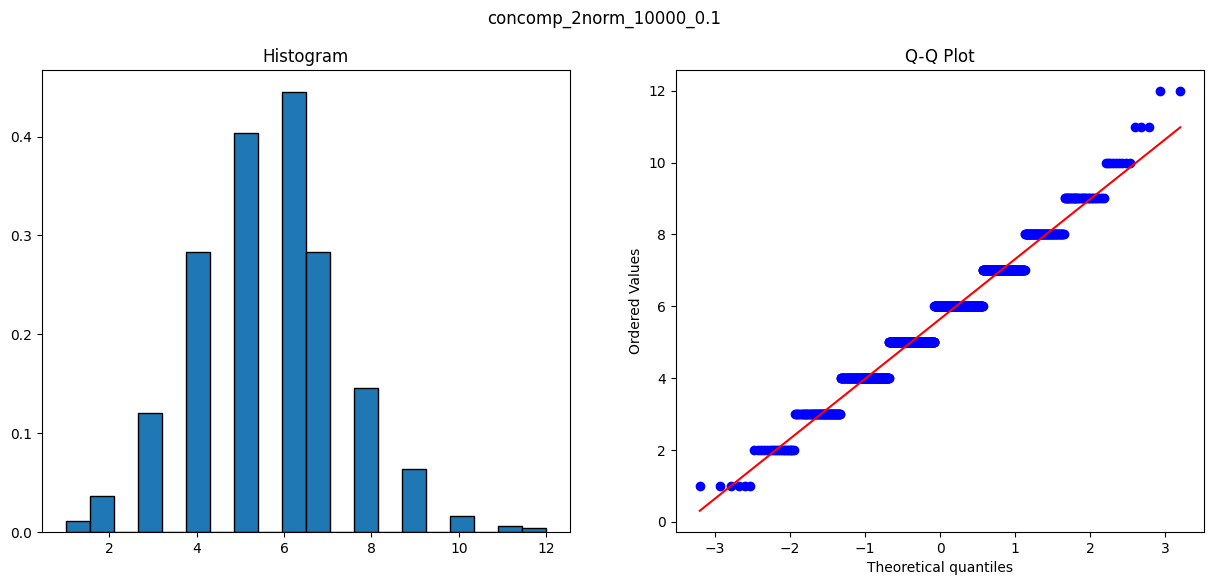

In [213]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

freq, edges = np.histogram(result, bins=20, density=True)
ax[0].bar(edges[:-1], freq, width=np.diff(edges), edgecolor="black", align="edge")
ax[0].set_title('Histogram')

result_array = np.asarray(result)
stats.probplot(result_array, rvalue=False, plot=ax[1])
ax[1].set_title('Q-Q Plot')

plt.suptitle(f'{type_}_{distrib}_{N}_{delta}')

In [29]:
types = ['triang', 'edges', 'concomp', 'indep', 'chrom']
distribs = ['uni', 'exp', 'norm']
Ns = [100, 10000, 100000]
deltas = [lambda x: 0.1, lambda x: 1/math.log(x), lambda x: 1/math.cbrt(x), lambda x: 1/math.sqrt(x), lambda x: 1/x]
deltas_names = ["const", "1/logN", "1/cbrtN", "1/sqrtN", "1/N"]

In [200]:
types = ['edges']
distribs = ['norm', '2norm']
Ns = [100, 1000, 10000, 100000]
deltas = [lambda x: 1/x]
deltas_names = ["1/N"]
cpp_executable = "./triang_transform"

uni 100 0.01
uni 1000 0.001


FileNotFoundError: [Errno 2] No such file or directory: 'triang/uni/1000/0_0.001.png'

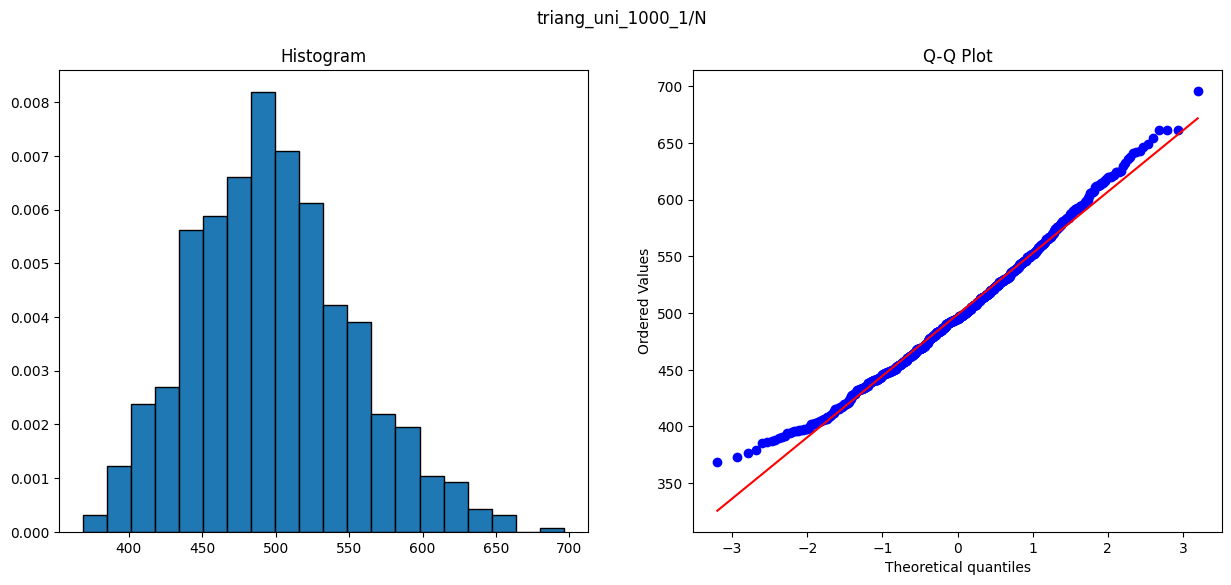

In [115]:
for type__ in types:
    for distrib_ in distribs:
        for N_ in Ns:
            for index, func in enumerate(deltas):
                delta_ = round(func(N_), 10)
                input_args = list(map(str, [N_, delta_, reps, distrib_, type__]))
                command = [cpp_executable] + input_args
                process = subprocess.run(
                    command,
                    text=True,
                    stdout=subprocess.PIPE
                )
                print(distrib_, N_, delta_)
                with open(output_file, 'r', encoding='utf-8') as f:
                    file = f.read()
                file = list(map(float, file.split()))
                data = pd.Series(file)
                result = data
                fig, ax = plt.subplots(1, 2, figsize=(15, 6))
                
                freq, edges = np.histogram(result, bins=20, density=True)
                ax[0].bar(edges[:-1], freq, width=np.diff(edges), edgecolor="black", align="edge")
                ax[0].set_title('Histogram')
                
                result_array = np.asarray(result)
                stats.probplot(result_array, rvalue=False, plot=ax[1])
                ax[1].set_title('Q-Q Plot')
                plt.suptitle(f'{type__}_{distrib_}_{N_}_{deltas_names[index]}')
                fig.savefig(f'{type__}/{distrib_}/{N_}/{index}_{delta_}.png')
                plt.close()

In [198]:
df = pd.DataFrame(columns=["result", "type", "distrib", "N", "delta"])
for type__ in types:
    for distrib_ in distribs:
        for N_ in Ns:
            for index, func in enumerate(deltas):
                delta_ = round(func(N_), 10)
                input_args = list(map(str, [N_, delta_, reps, distrib_, type__]))
                command = [cpp_executable] + input_args
                process = subprocess.run(
                    command,
                    text=True,
                    stdout=subprocess.PIPE
                )
                
                with open(output_file, 'r', encoding='utf-8') as f:
                    file = f.read()
                file = list(map(float, file.split()))
                data = pd.Series(file)
                tmp_df = data.to_frame(name="result")
                tmp_df.result = (tmp_df.result - tmp_df.result.mean()) / tmp_df.result.std()
                tmp_df["type"] = type__
                tmp_df["distrib"] = distrib_
                tmp_df["N"] = str(N_)
                tmp_df["delta"] = deltas_names[index]
                df = pd.concat([df] + [tmp_df], ignore_index=True)

/var/folders/lj/28jgzr052fj95v92y4vr_bh40000gn/T/ipykernel_79713/1989474063.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df] + [tmp_df], ignore_index=True)


<Axes: xlabel='cumsum', ylabel='N'>

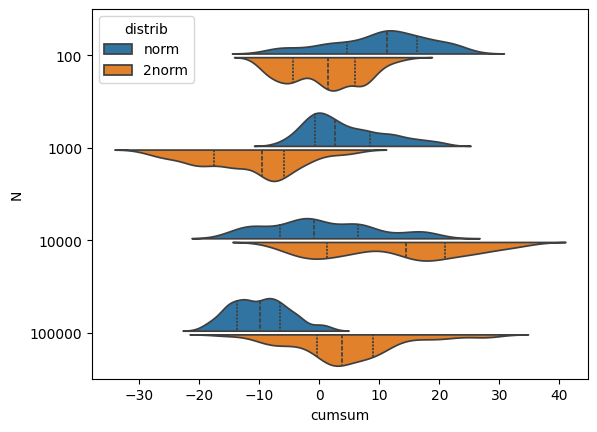

In [229]:
violinplot(data=df, x = "cumsum", y = "N", hue = "distrib", split="True", inner="quart", gap = 0.1)

In [231]:
df.query("N == '10000'")

,result,type,distrib,N,delta,cumsum
2000,0.805810,edges,norm,10000,1/N,8.058101e-01
2001,0.268448,edges,norm,10000,1/N,1.074258e+00
2002,1.361084,edges,norm,10000,1/N,2.435342e+00
2003,-0.609243,edges,norm,10000,1/N,1.826099e+00
2004,-0.071881,edges,norm,10000,1/N,1.754218e+00
...,...,...,...,...,...,...
6995,-1.598591,edges,2norm,10000,1/N,1.734697e+00
6996,-0.027308,edges,2norm,10000,1/N,1.707389e+00
6997,-0.623312,edges,2norm,10000,1/N,1.084077e+00
6998,-0.867132,edges,2norm,10000,1/N,2.169455e-01
